# Week 9 - Earthquakes and regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In this notebook, we will explore the earthquake catalog data for the Bay Area and compute the earthquake occurrence statistics: Omori's Law and Gutenberg-Richter Law.

These information will be useful for understanding the earthquake hazard and making earthquake forecasts (one of the optional final homeworks).

There are two primary statistics that describe earthquake catalog data. 

The first is Gutenberg-Richter, which is used to characterize the rates of primary earthquakes over some period of time to determine rates of occurence, which can then be used to assess hazards and make earthquake forecasts.

$$ log_{10}N(M) = A - b \cdot M $$

where $N(M)$ is the number of earthquakes at or above a magnitude $M$.

The second is Omori's Law which describes the distribution of aftershocks following a primary earthquake or mainshock. It can be used to estimate the rate of aftershock production over time after the earthquake (and the rate of decay in aftershock production).

$$ N(t) = \frac{k}{(c + t)^p} $$

<!-- $$ log_{10}N(t) = log_{10}k - p \cdot log_{10}(c + t) $$ -->

where $N(t)$ is the number of aftershocks after $t$ days, $k$ is a constant, $c$ is the time at which the aftershock production rate peaks (later on we'll assume this is 0 for simplicity; i.e., aftershock production peaks immidiately following the main earthquake), and $p$ is the decay rate.

Let's look at earthquakes that occurred close to Berkeley.

In particular, on October 17 at 5:15pm PDT (October 18 1989 at 04:15am UTC) the M6.9 Loma Prieta earthquake occurred in the Santa Cruz mountains approximately 80 km southwest of the Berkeley Campus. 

We will use the earthquake catalog in the Bay Area and aftershocks of the Loma Prieta earthquake to examine the earthquake statistics.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/84/USGS_Shakemap_-_1989_Loma_Prieta_earthquake_%28June_1988_foreshock%29.jpg" width=30%>

https://en.wikipedia.org/wiki/1989_Loma_Prieta_earthquake

## Exercise 1 - Earthquakes in the Bay Area

Start by loading the .csv data file of all the earthquakes from January 01,1989 to December 31, 1995 in the ANSS (Advanced National Seismic System) catalog from between latitudes 36.0-38.5° and longitude -123.0 to -121.0° ([http://ncedc.org/anss/catalog-search.html](http://ncedc.org/anss/catalog-search.html)).

In [2]:
## Load the Earthquake Catalog
catalog = pd.read_csv('data/bay_area_anss_1989_1995.csv')

## Convert the DateTime column to a datetime object
catalog['DateTime'] = pd.to_datetime(catalog['DateTime'])

## Preview the catalog
catalog.head()

,Unnamed: 0,DateTime,Latitude,Longitude,Depth,Magnitude,MagType,NbStations,Gap,Distance,RMS,Source,EventID
0,0,1989-01-01 03:51:37.170,36.5928,-121.1027,0.00,1.26,Md,4,150.0,6.0,0.13,NC,1160762.0
1,1,1989-01-01 11:39:34.870,36.9583,-121.5762,5.70,1.07,Md,34,36.0,1.0,0.08,NC,129467.0
2,2,1989-01-01 21:05:18.030,37.5293,-121.6905,7.03,0.99,Md,11,80.0,4.0,0.02,NC,129474.0
3,3,1989-01-01 21:54:27.470,37.5590,-121.6760,7.38,0.85,Md,12,66.0,1.0,0.04,NC,129475.0
4,4,1989-01-01 21:57:12.240,36.6493,-121.2678,4.66,1.17,Md,21,65.0,1.0,0.04,NC,129476.0


**(10 points)** Use your knowledge of matplotlib and cartopy to create a scatter plot of the earthquakes in this catalog. Add the location of the UC Berkeley campus (coordinates are given) as well as the coastline. Color the earthquakes by their magnitude.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


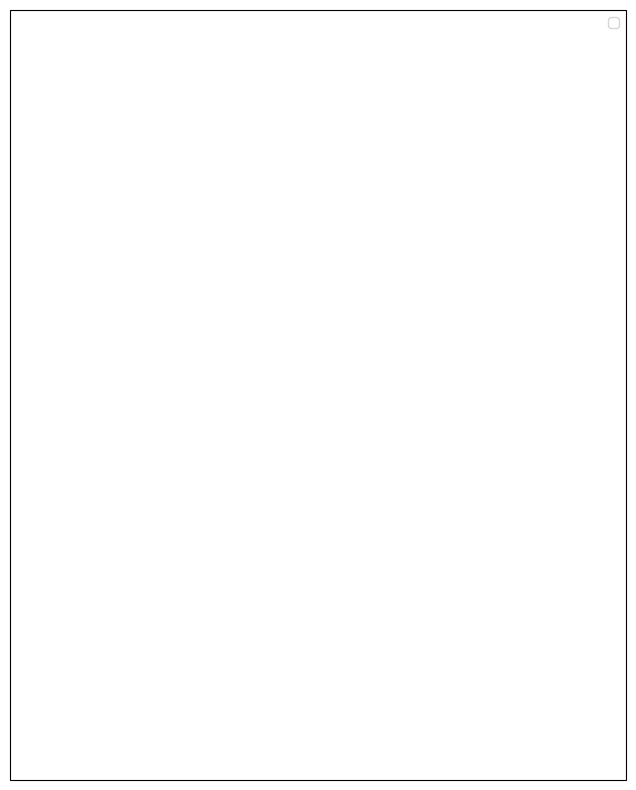

In [3]:
## Coordinates for UC Berkeley
Berk_lat = 37.8716
Berk_lon = -122.2727

## Coordinates for the map
lat0=36.0
lat1=38.5
lon0=-123.0
lon1=-121.0

## Make a map using cartopy
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())

## Plot the entire catalog


## Add coastlines


## Add Berkeley Campus. Remember to add `label='Berkeley Campus'` to the scatter plot.


# ## Add x and y labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

## Add legend
plt.legend()

plt.show()

First we will look at the earthquake frequency vs magnitude for the entire catalog. 

Based on the Gutenberg-Richter Law, we expect a linear relationship between the magnitude and the logarithmic number of earthquakes with that magnitude or higher.

$$ log_{10}N(M) = A - b \cdot M $$

**(10 points)** Plot a histogram of earthquake occurance (i.e., how many earthquakes in each bin) against magnitude.
You can use `plt.hist()` to plot the histogram of `catalog['Magnitude']`. Use `log=True` to plot the histogram on a log scale.

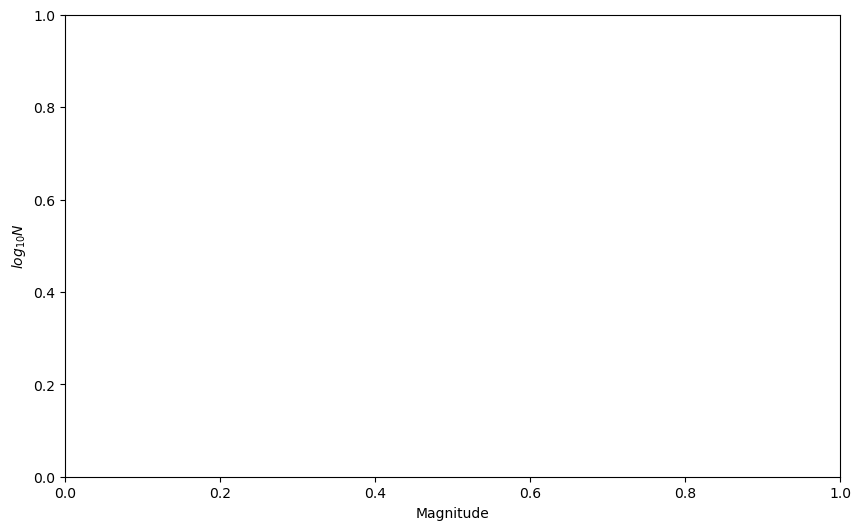

In [4]:
## Make a figure
plt.figure(figsize=(10, 6))

## Plot the histogram of earthquake frequency vs magnitude. 


## Set the y-axis in log scale. Hint: use plt.yscale(


## Add x-axis label and y-axis label
plt.xlabel('Magnitude')
plt.ylabel('$log_{10}N$')

plt.show()

## Exercise 2 - Linear regression to get the Gutenberg-Richter Parameters

**(10 points)** Using the ```LinearRegression()``` function from ```sklearn``` fit a linear regression model between the earthquake magnitudes and the frequency of earthquakes (of each magnitude). To do this we will first assign 'magnitude bins' and determine the frequency of each magnitude in these bins using the ```np.histogram``` function. You then need to follow the instructions/comments below to complete the code. When you've made the model, calculate the predicted number of earthquakes in each bin over this time period and plot the results (plot the prediction as a line with frequency vs magnitude_bins as a scatter plot).

In [5]:
## We can use the np.histogram function to get the frequency of each magnitude bin. 
# Hint: define magnitude_bins between M -0.05 and M6.05 with a bin size of M0.1
magnitude_bins = np.arange(-0.05, 6.05, 0.1)
event_bins, _ = np.histogram(catalog['Magnitude'], bins=magnitude_bins)
event_cumulative = np.flip(np.cumsum(np.flip(event_bins)))

## Redefine the magnitude_bins to be the bin centers, because the histogram function is using the bin edges.
magnitude_bins = (magnitude_bins[:-1] + magnitude_bins[1:]) / 2

## Define the input and output variables. Hint: use `np.log10(frequency)` to take the logarithm of the frequency
X = 
y = 

## filter out the inf values
X = X[~np.isinf(y)]
y = y[~np.isinf(y)]

## Reshape the input and output variables to be vertical arrays. Hint: use the `reshape(-1, 1)` method
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

## Fit a linear model using LinearRegression() from sklearn
model = 


## Get prediction from the model


## Plot the prediction
plt.figure(figsize=(10, 6))

plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

Hopefully you can all see this isn't a great fit. Before we discuss why, let's consider a few different approaches we could take to evaluate the performance of a Linear Regression such as this. 

**(5 points)** The first option is to consider the $r^2$ value, which describes the strength of the relationship between two the predicted and observed earthquake frequencies. Calculate the $r^2$ value using the ```r2_score``` function from ```sklearn``` and calculate it manually using the equation shown in class.

**(5 points)** The other thing we can do is calculate the residual between the predicted (model results) and observed earthquake frequencies. Do this calculation in the cell below and then plot the residuals against earthquake magnitude

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


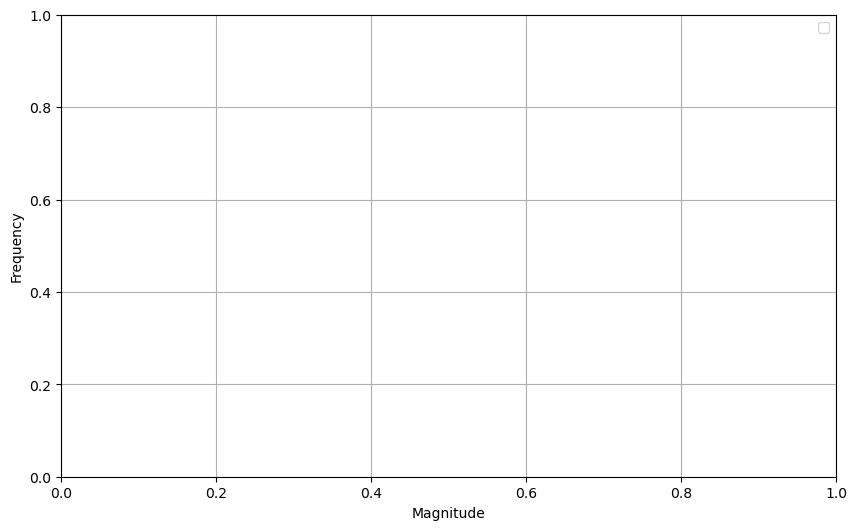

In [6]:


## Plot the prediction
plt.figure(figsize=(10, 6))

plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

The reason the model does not fit well at the small magnitude earthquakes (M < 1) is because the earthquake catalog is not complete for small magnitude earthquakes meaning that there are many small magnitude earthquakes that are not recorded in the catalog because of many reasons such as the earthquakes are too far away from the seismic stations, the earthquakes are too weak to be recorded by the seismographs, and the background noise level is too high for automatic algorithms to identify the earthquakes.

**(15 points)** To fix the fit, let's only fit the data for M >= 1. This is going to use the same process as above, but we'll add an additional step  to filter out any earthquakes with a magnitude less than 1. Again plot the predictions against the observations and calculate the $r^2$ value.

In [7]:
## We can use the np.histogram function to get the frequency of each magnitude bin. 
magnitude_bins = np.arange(0.05, 6.05, 0.1)
event_bins, _ = np.histogram(catalog['Magnitude'], bins=magnitude_bins)
event_cumulative = np.flip(np.cumsum(np.flip(event_bins)))

## Redefine the magnitude_bins to be the bin centers, because the histogram function is using the bin edges.
magnitude_bins = (magnitude_bins[:-1] + magnitude_bins[1:]) / 2

## Define the input and output variables. Hint: use `np.log10(frequency)` to take the logarithm of the frequency
X = 
y = 

## filter according to magnitude - only include earthquakes with Mag > 1
y = y[
X = X[

## filter out the inf values
X = X[~np.isinf(y)]
y = y[~np.isinf(y)]

## Reshape the input and output variables to be vertical arrays. Hint: use the `reshape(-1, 1)` method
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

## Fit a linear model using LinearRegression() from sklearn
model = 


## Get prediction from the model


## Evaluate the model using r2_score

print(f'The model R-squared is {R_squared:.2f}')

## Plot the prediction
plt.figure(figsize=(10, 6))

plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

**(5 points)** What is the slope and intercept of the linear model? Can you estimate the A-value and b-value of the Gutenberg-Richter Law? 

$$ log_{10}N(M) = A - b \cdot M $$

## Exercise 3 - Aftershocks following the Loma Prieta earthquake

Let's now look at the aftershocks of the Loma Prieta earthquake.

First, we need to extract the period of the Loma Prieta earthquake. We can do this by setting the time and location (lat and long) of the earthquake and then creating a new DataFrame that contains only the earthquakes located within 90 days of the main shock and within +/- 0.1 degress longitude and latitude.

**(5 points)** Complete the code below to create the new, filtered DataFrame.

In [34]:
## Define the earthquake origin time, latitude, and longitude (https://earthquake.usgs.gov/earthquakes/eventpage/nc216859/executive)
earthquake_origin_time = pd.to_datetime('1989-10-18 00:04:15')
earthquake_latitude = 37.036
earthquake_longitude = -121.885

## Define a new column of days since the earthquake origin time. 
catalog['days_since_earthquake'] = (catalog['DateTime'] - earthquake_origin_time).dt.days

## Extract the earthquakes within 0.1 degree from the earthquake origin and within 90 days from the earthquake origin time
## Fill in the missing information
LP_catalog = catalog[
    (catalog['days_since_earthquake'] >= ) & 
    (catalog['days_since_earthquake'] <= ) & 
    (catalog['Latitude'] >= ) & 
    (catalog['Latitude'] <= ) & 
    (catalog['Longitude'] >= ) & 
    (catalog['Longitude'] <= )
    ].copy()

**(5 points)** Plot magnitude vs. time (x axis) for the aftershock events

You can try to use `s=LP_catalog['Magnitude']` to scale the marker size by magnitude, or `c=LP_catalog['Magnitude']` to color the marker by magnitude, cmap='plasma' seems to be a nice color map.

How would you describe the distribution of large earthquakes (M > 3) with time.

In [8]:
## Make the figure size wide using `figsize=(20, 6)`
plt.figure(figsize=(20, 6))

## Plot the Loma Prieta aftershock catalog using 'DateTime' and 'Magnitude'


## Add a color bar
plt.colorbar(label='Magnitude')

## Add x-axis label and y-axis label
plt.xlabel('Time')
plt.ylabel('Magnitude')

plt.show()

**(5 points)** Plot a histogram of earthquake frequency vs time. The code sets up 5-day bins for this analysis.

How would you describe the distribution of number of aftershocks with time after the main quake? What is the peak time of aftershock production? How does the aftershock rate decay with time?

In [10]:
## Make a figure
plt.figure(figsize=(10, 6))

## Define bins from 0 to 90 days with a bin size of 5 days.
days_bins = np.arange(0, 91, 5)

## Plot the histogram of earthquake frequency vs time. Hint: add bins=days_bins

## Add x-axis label and y-axis label

plt.show()

<Figure size 1000x600 with 0 Axes>

Let's see if we can do some quantitative analysis of the aftershock rate decay with time.

The challenge is that the Omori's law is not a linear relationship, but a power law relationship. 

$$ N(t) = \frac{k}{(c + t)^p} $$ 

Let's first convert the equation to a linear form.

$$ log_{10}N(t) = log_{10}k - p \cdot log_{10}(c + t) $$

For simplicity let's assume `c=0` and fit the data to the linear model. 

$$ log_{10}N(t) = log_{10}k - p \cdot log_{10}(t) $$

So the y value is `log10(N(t))` and the x value is `log10(t)`.

**(15 points)** Fit a Linear Regression model to the aftershock data to estimate the $log_{10}k$ and $p$ parameters. Plot the earthquake frequency vs time (as a scatter plot) with the regression model overlain as a single line. Remember to also calculate the $r^2$ parameter for this regression.

In [11]:
## Calcualte frequency of earthquakes using np.histogram. Using using days_bins between 0 and 90 days for every 5 days.
days_bins = np.arange(0, 90, 5)
frequency, bins = np.histogram(LP_catalog['days_since_earthquake'], bins = days_bins)

## Calculate the days on bin centers becuase the "bins" variable is defined as the bin edges
days_bins = (bins[:-1] + bins[1:]) / 2

## Define the input and output variables. Hint: use `np.log10(frequency)` to take the logarithm of the frequency and `np.log10(days_bins)` to take the logarithm of the days_bins
X = 
y = 

## filter out the inf values
X = X[~np.isinf(y)]
y = y[~np.isinf(y)]

## Reshape the input and output variables to be vertical arrays
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

## Fit a linear model using LinearRegression() from sklearn
model = 

## Get prediction from the model


## Evaluate the model using r2_score

print(f'The model R-squared is {R_squared:.2f}')

## Plot the prediction
plt.figure(figsize=(10, 6))

plt.legend()
plt.grid()

plt.show()

## Earthquake recurrence in the San Francisco Bay Area

Both the Gutenberg-Richter Law and Omori's Law are very important for understanding the earthquake recurrence in a region.

Based on the full 120 year catalog, we can estimate the average recurrence interval for magnitude 5.0, 6.0, 7.0 and 8.0 events in the San Francisco Bay Area. This is included as one of the additional homeworks in this class. 

The bay area is located on the San Andreas Fault, which is the boundary between the Pacific and North American tectonic plates.

You can read more information about earthquake hazard of the San Andreas Fault from the USGS website:

https://www.usgs.gov/natural-hazards/earthquake-hazards/science/back-future-san-andreas-fault?qt-science_center_objects=0#qt-science_center_objects

Although we can not predict when and where the next big earthquake will happen, understanding the earthquake recurrence can help us prepare for the earthquake and mitigate the earthquake risk.

Earthquake forecasting and earthquake risk assessment is an important topic in the field of earthquake engineering.

You can read more about earthquake forecasting and risk assessment from our BLS website:

https://seismo.berkeley.edu/research/eew_basics.html

<img src="figures/fault_map.png" width=700>

Map of Bay Area faults. 
Source: https://pubs.er.usgs.gov/publication/fs20163020